## Carregamento e conhecimento inicial dos dados

In [30]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("work/datasets/hotel_bookings.csv")

df.head() # mostra toda a estrutura da tabela
df.shape # mostra o numero de linhas e colunas
df.info() # mostra o tipo do atributo de cada coluna

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

#### 1. Quantas instâncias e quantos atributos existem?
Existem 119390 instancias(linhas) e 32 atributos(colunas)

#### 2. Quais atributos são numéricos e quais são categóricos?

In [31]:
display(f"Numericos: {df.select_dtypes(include=["number"]).columns.tolist()}")
display(f"Categoricos: {df.select_dtypes(include=["category", "string", "object"]).columns.tolist()}")

"Numericos: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']"

"Categoricos: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']"

#### 3. Quais atributos são binários?

In [32]:
print(f"As colunas binarias sao: {[col for col in df.columns if df[col].nunique() == 2]}")

As colunas binarias sao: ['hotel', 'is_canceled', 'is_repeated_guest']


#### 4. Quais atributos representam características da reserva, do cliente, da  estadia e do hotel?

In [33]:
print(df.columns.tolist()) #vou pular essa questao devido ao trabalho para categorizar os dados, isso nao tem uma forma de fazer automatica

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


## Qualidade dos dados

In [34]:
# o isnull mostra a coluna passando true ou false 
# em cada linha da coluna que tem um valor vazio.
# Ja p sum() mostra a quantidade existente de valores
# vazios em cada coluna.
df.isnull().sum() 

# O dupicated  Ele dá True se a linha inteira for idêntica a 
# uma linha anterior e False se for uma linha inédita , ja o 
# sum() mostra a soma de todos esses "trues"
df.duplicated().sum()

# O  nunique serve para mostrar a quantidade de valores distindo que 
# existe para cada coluna, descartando os valores nulos
df.nunique()


hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

#### 5. Existem valores faltantes? Em quais atributos e em que quantidade?

In [35]:
# duas maneiras de fazer essa busca por colunas com valores nulos
print(f"Colunas com valores nulos: {[col for col in df.columns if df[col].isnull().any()]}")
print(f"Colunas com valores nulos: {df.columns[df.isnull().any()].tolist()}")

Colunas com valores nulos: ['children', 'country', 'agent', 'company']
Colunas com valores nulos: ['children', 'country', 'agent', 'company']


#### 6. Existem registros duplicados?

In [36]:
print(f"Existem: {df.duplicated().sum()} valores duplicados") 

Existem: 31994 valores duplicados


#### 7. Quais atributos possuem grande quantidade de valores distintos?

In [37]:
print(f"Os atrinutos: {df.columns[df.nunique() > 100].tolist()}")

Os atrinutos: ['lead_time', 'country', 'agent', 'company', 'days_in_waiting_list', 'adr', 'reservation_status_date']


#### 8. Quais problemas de qualidade precisam ser considerados antes de uma análise posterior?
Talvez outliers, valores ausentes, valores incorretos ou que nao fazem sentido, dentre varios.

## Estatística descritiva

In [38]:
main_columns = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children",
"babies", "previous_cancellations", "booking_changes", "days_in_waiting_list", "adr",
 "total_of_special_requests"]

resume = df[main_columns].describe()

resume.loc["amplitude"] = resume.loc["max"] - resume.loc["min"]
resume.loc["IQR"] = resume.loc["75%"] - resume.loc["25%"]

display(resume)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,0.087118,0.221124,2.321149,101.831122,0.571363
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,0.844336,0.652306,17.594721,50.535790,0.792798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,1.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5400.000000,5.000000
amplitude,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5406.380000,5.000000
IQR,142.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.710000,1.000000


 ## Visualizações e perguntas de investigaçã

Text(0, 0.5, 'frequência')

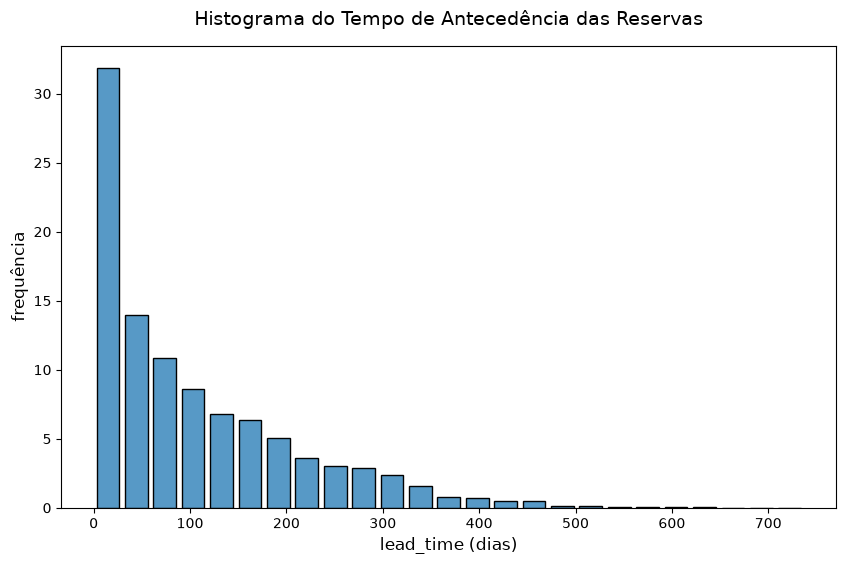

In [46]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="lead_time", bins=25, shrink=0.80, stat="percent")

plt.title('Histograma do Tempo de Antecedência das Reservas', fontsize=14, pad=15)
plt.xlabel('lead_time (dias)', fontsize=12)
plt.ylabel('frequência', fontsize=12)


#### 1. Em que faixa de antecedência está concentrada a maior parte das reservas?
A maior parte das reservas esta concentrada enttre 0 e 100 dias.
#### 2. A distribuição parece simétrica ou assimétrica?
A distribuição é assimetrica, especificando, assimettrica positiva. 
#### 3. Existe uma cauda longa para valores elevados?
sim, uma cauda esticando a direita.
#### 4. Há indícios de valores extremos?
Sim. Há indícios de valores extremos (outliers) na extrema direita do gráfico, com registros isolados de reservas feitas com mais de 500, 600 ou até 700 dias de antecedência (quase 2 anos antes), o que é totalmente fora do padrão comum.
#### 5. O que o formato sugere sobre o planejamento das reservas?
As pessoas tem preferencia em reservar mais em "em cima" da hora, nao buscam reservas com antecedencia.